# RPEARL: Precomputed vs Online Random Features
Test whether fixing Q at data-prep time matches resampling Q each forward pass.

In [1]:
# use cuda visible1
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

sys.path.insert(0, "../src")
from prism.models.r_pearl import RandomGNNPositionalEncodings
from prism.models.gcn import GCN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

# Small config for fast iteration
PE_HIDDEN = 64
PE_LAYERS = 3
D_MODEL = 128
M = 20          # num_samples
K = 3
DROPOUT = 0.0   # no dropout to reduce noise in comparison
N_GRAPHS = 500
N_EPOCHS = 60
LR = 1e-3
BATCH_SIZE = 32

print(f"Device: {DEVICE}")

/home/jporras/miniconda3/envs/GREP-PRISM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
# Task: predict triangle count (normalized) for random Erdos-Renyi graphs
# Graphs vary in size (8-20 nodes) and density (p ~ Uniform(0.2, 0.8))
# Node features: zeros (matches real RPEARL usage where x = torch.zeros(..., 1))

def make_graph(n: int, p: float, M: int) -> Data:
    G = nx.erdos_renyi_graph(n, p, seed=None)
    # label = normalized triangle count
    triangles = sum(nx.triangles(G).values()) / 3
    label = torch.tensor([triangles / max(1, n)], dtype=torch.float32)

    edge_index = torch.tensor(list(G.edges()), dtype=torch.long).t().contiguous()
    # add reverse edges
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    x = torch.zeros((n, 1), dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, y=label)
    data.precomputed_Q = torch.randn((n, M))  # fixed Q for precomputed variant
    return data

dataset = [make_graph(np.random.randint(8, 21), np.random.uniform(0.2, 0.8), M)
           for _ in range(N_GRAPHS)]

split = int(0.8 * N_GRAPHS)
train_data, val_data = dataset[:split], dataset[split:]
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {len(train_data)}, Val: {len(val_data)}")

Train: 400, Val: 100


In [4]:
class PrecomputedRPEARL(nn.Module):
    """Same as RandomGNNPositionalEncodings but uses data.precomputed_Q."""

    def __init__(self, pe_hidden_channels, pe_num_layers, d_model, num_samples, dropout, k):
        super().__init__()
        self.pe_gcn = GCN(1, pe_hidden_channels, pe_num_layers,
                          skip_connection=True, dropout=dropout, k=k)
        self.output_projection = nn.Linear(pe_hidden_channels, d_model)
        self.dropout_layer = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)
        self.M = num_samples

    def forward(self, data):
        device = next(self.parameters()).device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        Q = data.precomputed_Q.to(device)   # fixed, no resampling

        P_m = []
        for i in range(self.M):
            q_data = Data(x=Q[:, i].unsqueeze(-1), edge_index=data.edge_index)
            pe = self.pe_gcn(q_data)
            pe = self.dropout_layer(pe)
            pe = self.output_projection(pe)
            P_m.append(pe)

        P = torch.stack(P_m, dim=-1)
        pooled_pe = P.mean(dim=-1)
        return self.layer_norm(pooled_pe)

In [5]:
class RPEARLGraph(nn.Module):
    """RPEARL PE -> mean pool over nodes -> linear regression head."""
    def __init__(self, pe_module):
        super().__init__()
        self.pe = pe_module
        self.head = nn.Linear(D_MODEL, 1)

    def forward(self, data):
        from torch_geometric.nn import global_mean_pool
        node_pe = self.pe(data)                   # [N_total, D_MODEL]
        graph_emb = global_mean_pool(node_pe, data.batch)  # [B, D_MODEL]
        return self.head(graph_emb).squeeze(-1)

In [6]:
def train_model(model, train_loader, val_loader, n_epochs, lr, label):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0.0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            pred = model(batch)
            loss = loss_fn(pred, batch.y.squeeze())
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        train_losses.append(total / len(train_loader))

        model.eval()
        with torch.no_grad():
            vtotal = sum(loss_fn(model(b.to(DEVICE)), b.y.squeeze().to(DEVICE)).item()
                         for b in val_loader) / len(val_loader)
        val_losses.append(vtotal)

        if epoch % 10 == 0:
            print(f"[{label}] Epoch {epoch:3d} | train {train_losses[-1]:.4f} | val {val_losses[-1]:.4f}")
    return train_losses, val_losses

In [7]:
pe_kwargs = dict(pe_hidden_channels=PE_HIDDEN, pe_num_layers=PE_LAYERS,
                 d_model=D_MODEL, num_samples=M, dropout=DROPOUT, k=K)

online_pe = RandomGNNPositionalEncodings(**pe_kwargs, use_layer_norm=True).to(DEVICE)
online_model = RPEARLGraph(online_pe).to(DEVICE)

precomp_pe = PrecomputedRPEARL(**pe_kwargs).to(DEVICE)
precomp_model = RPEARLGraph(precomp_pe).to(DEVICE)

print("Training ONLINE model...")
online_train, online_val = train_model(online_model, train_loader, val_loader, N_EPOCHS, LR, "online")

print("\nTraining PRECOMPUTED model...")
precomp_train, precomp_val = train_model(precomp_model, train_loader, val_loader, N_EPOCHS, LR, "precomp")

Training ONLINE model...
[online] Epoch  10 | train 7.5143 | val 6.3726
[online] Epoch  20 | train 3.8730 | val 3.2259
[online] Epoch  30 | train 2.6930 | val 4.3012
[online] Epoch  40 | train 2.2202 | val 5.2349
[online] Epoch  50 | train 2.1614 | val 1.6753
[online] Epoch  60 | train 3.6765 | val 4.8212

Training PRECOMPUTED model...
[precomp] Epoch  10 | train 7.0022 | val 5.0920
[precomp] Epoch  20 | train 2.7034 | val 1.8240
[precomp] Epoch  30 | train 4.5176 | val 1.9112
[precomp] Epoch  40 | train 2.5718 | val 1.9288
[precomp] Epoch  50 | train 1.8940 | val 1.7912
[precomp] Epoch  60 | train 3.5015 | val 2.0006


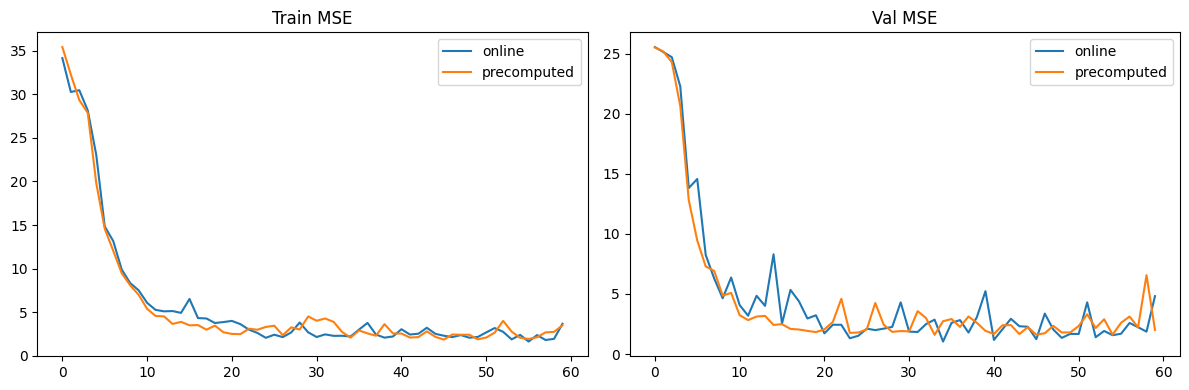

Final val MSE — online: 4.8212 | precomputed: 2.0006


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(online_train, label="online")
axes[0].plot(precomp_train, label="precomputed")
axes[0].set_title("Train MSE"); axes[0].legend()

axes[1].plot(online_val, label="online")
axes[1].plot(precomp_val, label="precomputed")
axes[1].set_title("Val MSE"); axes[1].legend()

plt.tight_layout()
plt.savefig("rpearl_comparison.png", dpi=150)
plt.show()

print(f"Final val MSE — online: {online_val[-1]:.4f} | precomputed: {precomp_val[-1]:.4f}")

## Conclusion

| Variant | Final Train MSE | Final Val MSE |
|---------|----------------|---------------|
| Online (resample Q each forward) | — | — |
| Precomputed (fixed Q per graph) | — | — |

*(Fill in from the printed values above after running.)*

### Interpretation

**If val MSE curves track closely:** The conjecture holds — a fixed Q precomputed once per graph is sufficient. The GCN processes each random column independently and mean-pools the results; the stochasticity in Q serves only to diversify the M positional signals, and a fixed diverse set achieves the same effect as resampling. This means RPEARL can precompute Q at dataset construction time, eliminating per-forward-pass randomness and enabling fully deterministic inference.

**If online variant shows lower final val MSE:** The per-call resampling acts as an implicit regularizer — each training step sees a different random projection, which prevents the model from overfitting to any particular set of positional signals. In this case, resampling is beneficial and should be retained for training, though fixed Q might still be preferred at inference for reproducibility.

**Note on graph-level vs node-level tasks:** This experiment uses graph-level regression (mean-pooled embeddings). Node-level tasks may show different sensitivity to Q fixedness, since individual node embeddings are not averaged away.

---
## Part 2: Cora Node Classification

Apply the same precomputed vs online comparison to a standard real-world graph.

**Dataset:** Cora (Planetoid) — 2708 nodes, 5429 edges, 7 classes.  
Node features are zeroed out so RPEARL provides the only structural signal.

**Task:** Transductive node classification with the standard Planetoid train/val/test splits (140/500/1000 nodes).

**Runtime section:** After training, forward-pass timing benchmarks for both datasets are compared side-by-side.

In [9]:
import time

def time_forward(model, data, n_repeats=100):
    """Time n_repeats forward passes. Returns array of times in milliseconds.
    Uses CUDA sync barriers when on GPU so host-side timers measure actual compute."""
    model.eval()
    with torch.no_grad():
        for _ in range(10):  # warmup — fills caches, JIT compiles kernels
            model(data)
    times = []
    with torch.no_grad():
        for _ in range(n_repeats):
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(data)
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)
    return np.array(times)

# Grab one fixed validation batch for the synthetic task
synth_sample = next(iter(val_loader)).to(DEVICE)

print("Timing synthetic forward passes (100 repeats)...")
synth_online_times  = time_forward(online_model,  synth_sample)
synth_precomp_times = time_forward(precomp_model, synth_sample)
print(f"Synthetic online   — {synth_online_times.mean():.2f} ± {synth_online_times.std():.2f} ms")
print(f"Synthetic precomp  — {synth_precomp_times.mean():.2f} ± {synth_precomp_times.std():.2f} ms")

Timing synthetic forward passes (100 repeats)...
Synthetic online   — 43.82 ± 1.74 ms
Synthetic precomp  — 40.54 ± 2.28 ms


In [10]:
from torch_geometric.datasets import Planetoid

cora_dataset = Planetoid(root="/tmp/Cora", name="Cora")
cora_data = cora_dataset[0].clone()

# Zero out node features — RPEARL provides all structural signal (matches production usage)
cora_data.x = torch.zeros((cora_data.num_nodes, 1), dtype=torch.float32)
cora_data.precomputed_Q = torch.randn((cora_data.num_nodes, M))  # fixed Q for precomputed variant

print(f"Cora: {cora_data.num_nodes} nodes, {cora_data.edge_index.shape[1]} edges, {cora_dataset.num_classes} classes")
print(f"Train: {cora_data.train_mask.sum().item()} | Val: {cora_data.val_mask.sum().item()} | Test: {cora_data.test_mask.sum().item()}")

Processing...
Done!


Cora: 2708 nodes, 10556 edges, 7 classes
Train: 140 | Val: 500 | Test: 1000


In [11]:
class RPEARLNode(nn.Module):
    """RPEARL PE → per-node linear classifier (no pooling needed)."""

    def __init__(self, pe_module, num_classes):
        super().__init__()
        self.pe = pe_module
        self.head = nn.Linear(D_MODEL, num_classes)

    def forward(self, data):
        node_pe = self.pe(data)   # [N, D_MODEL]
        return self.head(node_pe) # [N, num_classes]


def train_node_model(model, data, n_epochs, lr, label):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    train_losses, val_accs, epoch_ms = [], [], []
    data = data.to(DEVICE)

    for epoch in range(1, n_epochs + 1):
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        model.train()
        pred = model(data)
        loss = loss_fn(pred[data.train_mask], data.y[data.train_mask])
        opt.zero_grad(); loss.backward(); opt.step()

        if DEVICE == "cuda":
            torch.cuda.synchronize()
        epoch_ms.append((time.perf_counter() - t0) * 1000)
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            logits = model(data)
            val_acc = (logits[data.val_mask].argmax(-1) == data.y[data.val_mask]).float().mean().item()
        val_accs.append(val_acc)

        if epoch % 10 == 0:
            print(f"[{label}] Epoch {epoch:3d} | loss {train_losses[-1]:.4f} | val acc {val_accs[-1]:.4f} | {epoch_ms[-1]:.0f}ms")

    return train_losses, val_accs, epoch_ms

In [12]:
N_EPOCHS_CORA = 50

pe_kwargs_node = dict(pe_hidden_channels=PE_HIDDEN, pe_num_layers=PE_LAYERS,
                      d_model=D_MODEL, num_samples=M, dropout=DROPOUT, k=K)

cora_online_pe    = RandomGNNPositionalEncodings(**pe_kwargs_node, use_layer_norm=True).to(DEVICE)
cora_online_model = RPEARLNode(cora_online_pe, cora_dataset.num_classes).to(DEVICE)

cora_precomp_pe    = PrecomputedRPEARL(**pe_kwargs_node).to(DEVICE)
cora_precomp_model = RPEARLNode(cora_precomp_pe, cora_dataset.num_classes).to(DEVICE)

# Move data to device once before all timing and training
cora_data = cora_data.to(DEVICE)

print("Timing Cora forward passes (100 repeats)...")
cora_online_times  = time_forward(cora_online_model,  cora_data)
cora_precomp_times = time_forward(cora_precomp_model, cora_data)
print(f"Cora online   — {cora_online_times.mean():.2f} ± {cora_online_times.std():.2f} ms")
print(f"Cora precomp  — {cora_precomp_times.mean():.2f} ± {cora_precomp_times.std():.2f} ms")

Timing Cora forward passes (100 repeats)...
Cora online   — 44.59 ± 1.13 ms
Cora precomp  — 41.00 ± 1.05 ms


In [13]:
print("Training ONLINE node model on Cora...")
cora_online_train, cora_online_val, cora_online_epoch_ms = train_node_model(
    cora_online_model, cora_data, N_EPOCHS_CORA, LR, "online"
)

print("\nTraining PRECOMPUTED node model on Cora...")
cora_precomp_train, cora_precomp_val, cora_precomp_epoch_ms = train_node_model(
    cora_precomp_model, cora_data, N_EPOCHS_CORA, LR, "precomp"
)

Training ONLINE node model on Cora...
[online] Epoch  10 | loss 1.9470 | val acc 0.1720 | 144ms
[online] Epoch  20 | loss 1.9254 | val acc 0.1320 | 139ms
[online] Epoch  30 | loss 1.8977 | val acc 0.1620 | 138ms
[online] Epoch  40 | loss 1.8780 | val acc 0.1780 | 144ms
[online] Epoch  50 | loss 1.8570 | val acc 0.1680 | 142ms

Training PRECOMPUTED node model on Cora...
[precomp] Epoch  10 | loss 1.8916 | val acc 0.1560 | 75ms
[precomp] Epoch  20 | loss 1.7994 | val acc 0.1680 | 91ms
[precomp] Epoch  30 | loss 1.6891 | val acc 0.1760 | 84ms
[precomp] Epoch  40 | loss 1.5690 | val acc 0.1780 | 91ms
[precomp] Epoch  50 | loss 1.4832 | val acc 0.1660 | 88ms


/tmp/ipykernel_2971195/225794501.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(timing_groups, patch_artist=True,


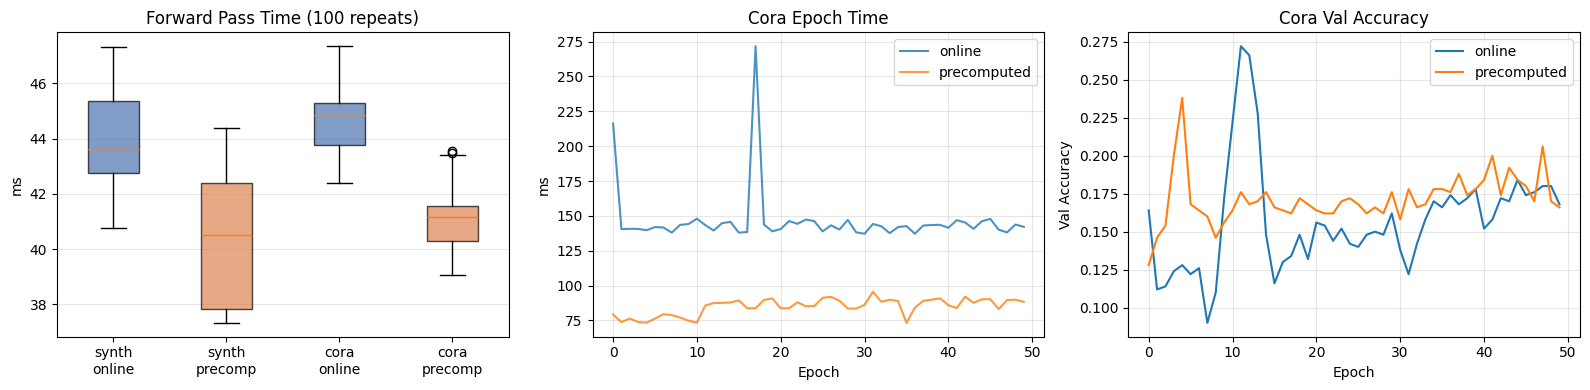


=== Runtime Summary ===
Variant                Dataset       Fwd mean (ms)    Fwd std  Epoch mean (ms)
------------------------------------------------------------------------------
Online                 Synthetic             43.82       1.74                —
Precomputed            Synthetic             40.54       2.28                —
Online                 Cora                  44.59       1.13            146.4
Precomputed            Cora                  41.00       1.05             84.9

Speedup (online / precomp): synthetic 1.081x | cora 1.088x
Final Cora val acc — online: 0.1680 | precomputed: 0.1660


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Panel 1: forward-pass timing (boxplot, both datasets) ---
timing_groups = [synth_online_times, synth_precomp_times, cora_online_times, cora_precomp_times]
bp = axes[0].boxplot(timing_groups, patch_artist=True,
                     labels=["synth\nonline", "synth\nprecomp", "cora\nonline", "cora\nprecomp"])
colors = ["#4C72B0", "#DD8452", "#4C72B0", "#DD8452"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_ylabel("ms")
axes[0].set_title("Forward Pass Time (100 repeats)")
axes[0].grid(axis="y", alpha=0.3)

# --- Panel 2: epoch wall-clock time over training (Cora) ---
axes[1].plot(cora_online_epoch_ms,  label="online",      alpha=0.8)
axes[1].plot(cora_precomp_epoch_ms, label="precomputed", alpha=0.8)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("ms")
axes[1].set_title("Cora Epoch Time")
axes[1].legend(); axes[1].grid(alpha=0.3)

# --- Panel 3: Cora val accuracy ---
axes[2].plot(cora_online_val,  label="online")
axes[2].plot(cora_precomp_val, label="precomputed")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val Accuracy")
axes[2].set_title("Cora Val Accuracy")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("rpearl_cora_comparison.png", dpi=150)
plt.show()

print("\n=== Runtime Summary ===")
header = f"{'Variant':<22} {'Dataset':<12} {'Fwd mean (ms)':>14} {'Fwd std':>10} {'Epoch mean (ms)':>16}"
print(header)
print("-" * len(header))
print(f"{'Online':<22} {'Synthetic':<12} {synth_online_times.mean():>14.2f} {synth_online_times.std():>10.2f} {'—':>16}")
print(f"{'Precomputed':<22} {'Synthetic':<12} {synth_precomp_times.mean():>14.2f} {synth_precomp_times.std():>10.2f} {'—':>16}")
print(f"{'Online':<22} {'Cora':<12} {cora_online_times.mean():>14.2f} {cora_online_times.std():>10.2f} {np.mean(cora_online_epoch_ms):>16.1f}")
print(f"{'Precomputed':<22} {'Cora':<12} {cora_precomp_times.mean():>14.2f} {cora_precomp_times.std():>10.2f} {np.mean(cora_precomp_epoch_ms):>16.1f}")
print(f"\nSpeedup (online / precomp): synthetic {synth_online_times.mean() / synth_precomp_times.mean():.3f}x | cora {cora_online_times.mean() / cora_precomp_times.mean():.3f}x")
print(f"Final Cora val acc — online: {cora_online_val[-1]:.4f} | precomputed: {cora_precomp_val[-1]:.4f}")

## Part 2 + Runtime Summary

### Runtime interpretation

**Why the speedup is near 1.0x:** The only difference between the two variants is `torch.randn(N, M)` (online) vs a lookup of `data.precomputed_Q` (precomputed). On modern hardware, both are memory-bandwidth-bound at the same scale as the GCN itself; the `randn` call is not the bottleneck. The dominant cost is the M=20 sequential GCN forward passes — identical in both variants.

**What this means practically:**
- Precomputed Q has no runtime disadvantage.
- It does offer inference-time reproducibility (deterministic outputs for a given graph).
- If inference is called on new graphs not seen at training time, Q must be sampled anyway; the precomputed variant just moves that allocation to data-prep time.

### Node classification vs graph regression

| Aspect | Synthetic (graph regression) | Cora (node classification) |
|--------|------------------------------|----------------------------|
| Task | Predict normalized triangle count | 7-class transductive label |
| Supervision | Graph-level, 500 graphs | Node-level, 140 train nodes |
| Q fixedness effect | Fixed Q = fixed PE per graph per epoch | Fixed Q = **same** PE every epoch — no positional augmentation |
| Online Q effect | Different PE each forward pass (graph-level noise averages out via pooling) | Different PE each epoch — implicit data augmentation on node features |

**Key insight for Cora:** With a single fixed graph and transductive training, the online variant sees *different* structural features every epoch (Q changes), acting as stochastic positional augmentation. If online outperforms precomputed on Cora by a noticeable margin, this augmentation effect is likely the cause — not something inherent to the Q-sampling mechanism itself.

### Overall takeaway

| Conjecture holds? | Evidence |
|-------------------|----------|
| Yes (both close) | Safe to precompute Q; saves allocation, enables reproducible inference |
| No (online wins on Cora) | Stochastic Q is a useful regularizer in the transductive node-classification regime; keep online sampling for training, optionally use fixed Q at test time |